## Feature Transformation and outliers handling
- we may experience sometimes that the data is left skewed or right skewed
- we resolve the outliers problems by two methods
- 1: clipping (remove the outliers)
- 2: winsorization (bring outliers to normal range)

In [33]:
import pandas as pd
import numpy as np

df=pd.read_csv('telecom_customer.csv')


In [34]:
# the issue
df[['monthly_income','monthly_bill']].describe()

,monthly_income,monthly_bill
count,1200.000000,1200.000000
mean,31155.975833,5939.150833
std,19351.937726,4046.473963
min,4984.000000,710.000000
25%,17795.000000,3291.750000
50%,26628.000000,4871.000000
75%,39886.250000,7485.500000
max,209790.000000,36361.000000


## plotting data to see skeweness

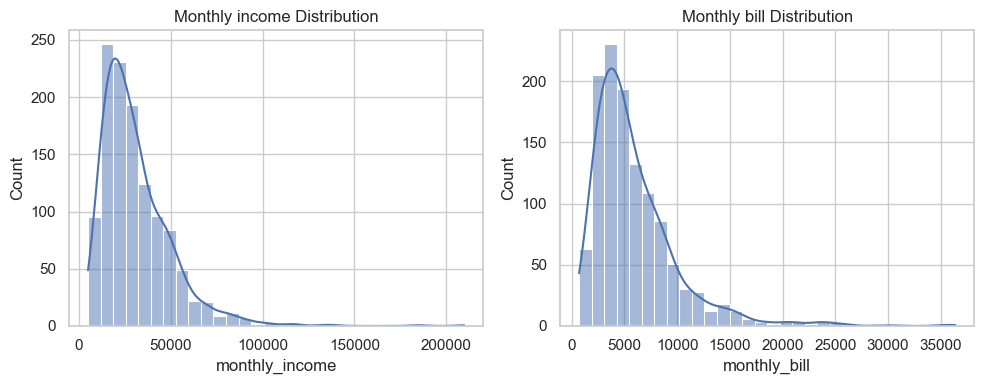

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

plt.figure(figsize=(10,4))

#plot 1 for monthly income
plt.subplot(1,2,1)
sns.histplot(df['monthly_income'],kde=True,bins=30)
plt.title("Monthly income Distribution")

#plot 2 for monthly bill
plt.subplot(1,2,2)
sns.histplot(df['monthly_bill'],kde=True,bins=30)
plt.title("Monthly bill Distribution")

plt.tight_layout()
plt.show()

## the issue
- data is right skewed in both columns

## We will use log transform for monthly income skeweness handling

In [36]:
df['monthly_income_log']=np.log1p(df['monthly_income'])

#side by side comparison
df[['monthly_income','monthly_income_log']].head()

,monthly_income,monthly_income_log
0,57643.0,10.962041
1,18207.0,9.809616
2,13075.0,9.478534
3,38890.0,10.568518
4,17475.0,9.768584


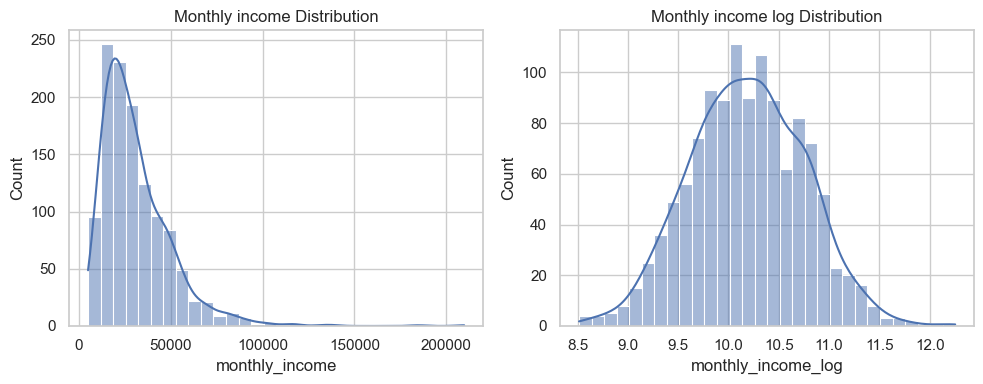

In [37]:
#visualizing to see the difference side by side 
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10,4))

#plot 1 for monthly income
plt.subplot(1,2,1)
sns.histplot(df['monthly_income'],kde=True,bins=30)
plt.title("Monthly income Distribution")

#plot 2 for monthly income log
plt.subplot(1,2,2)
sns.histplot(df['monthly_income_log'],kde=True,bins=30)
plt.title("Monthly income log Distribution")

plt.tight_layout()
plt.show()

In [38]:
#now we can see the income log is skewed perfectly

## handling outliers
- for monthly bill we will use clipping to handle outliers

In [39]:
upper_limit=df['monthly_bill'].quantile(0.99) #values above 99%
df['monthly_bill_clipped']=df['monthly_bill'].clip(upper=upper_limit)

In [40]:
df.loc[[df['monthly_bill'].idxmax(),df['monthly_bill'].sort_values().index[len(df)//2]],
       ['monthly_bill','monthly_bill_clipped']]

,monthly_bill,monthly_bill_clipped
968,36361.0,21696.4
47,4873.0,4873.0


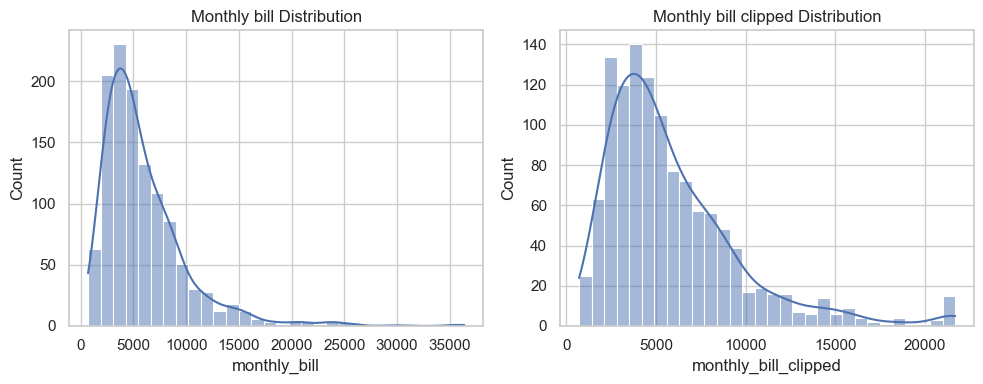

In [41]:
#visualizing monthly bill vs monthly bill clipped to see the difference side by side 
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10,4))

#plot 1 for monthly bill
plt.subplot(1,2,1)
sns.histplot(df['monthly_bill'],kde=True,bins=30)
plt.title("Monthly bill Distribution")

#plot 2 for monthly bill clipped
plt.subplot(1,2,2)
sns.histplot(df['monthly_bill_clipped'],kde=True,bins=30)
plt.title("Monthly bill clipped Distribution")

plt.tight_layout()
plt.show()

- now the clipped data is in range 0 to 2000 while the original was up to 35000